# Model Evaluation and Hyperparameter Tuning

CSI 4106 - Fall 2026

Marcel Turcotte  
Version: Sep 24, 2026 17:01

# Preamble

## Message of the Day

<https://youtu.be/UZ2duRYykkk>

<a href="https://youtu.be/UZ2duRYykkk" class="external"
data-icon="true">An OpenAI Engineer and His Friends Debate the
Future</a>, The New Yorker Documentary, 2026-09-23.

> **Note**
>
> A comedy writer explores the implications of artificial intelligence
> through a collaborative poetry book project with a childhood friend
> working at OpenAI. This personal journey examines the tension between
> professional ambitions in tech and the preservation of human
> creativity as the prospect of future superintelligence looms over
> their long-standing friendship.

Daniel Kokotajlo shared on X a personal statement about AI risk written
by Daniel Selsam, the OpenAI employee featured in the video.

## Learning Objectives

- **Distinguish** the roles of training, validation, and test data in
  model development and final evaluation.
- **Explain** how $k$-fold cross-validation trains a new model in each
  iteration and interpret the mean and standard deviation of its related
  fold scores.
- **Prevent** data leakage by fitting preprocessing within each fold and
  applying stored transformations to validation and test examples.
- **Distinguish** learned model parameters from hyperparameters and
  explain why interacting hyperparameters should be evaluated jointly.
- **Apply** `GridSearchCV` to tune multiple pipelines using a consistent
  metric and explain when randomized search is useful.
- **Compare** tuned model families, refit the selected pipeline on all
  training data, and evaluate it once on the untouched test set.

# Introduction

## Dataset: OpenML

>  **<a href="https://www.openml.org" class="external"
> data-icon="true">www.openml.org</a>**
>
> OpenML is an open platform for sharing datasets, algorithms, and
> experiments - to learn how to learn better, together.

. . .

In [1]:
import numpy as np
seed = 42

from sklearn.datasets import fetch_openml

diabetes = fetch_openml(name='diabetes', version=1)
print(diabetes.DESCR)

The Pima diabetes dataset contains 768 examples and eight numerical
attributes. It is compact enough to make repeated cross-validation
practical during class. Its restricted study population, age, and
data-quality limitations prevent the results from supporting broad
medical conclusions.

## Dataset: `return_X_y`

`fetch_openml` returns a `Bunch` by default, or `X` and `y` when
`return_X_y=True`.

In [2]:
X, y = fetch_openml(name='diabetes', version=1, return_X_y=True)

. . .

The positive class is less frequent, but both classes have enough
examples for stratified cross-validation.

In [3]:
print(y.value_counts())

class
tested_negative    500
tested_positive    268
Name: count, dtype: int64

. . .

Convert the target labels to 0 and 1:

In [4]:
y = y.map({'tested_negative': 0, 'tested_positive': 1})

The dataset contains 500 negative and 268 positive examples,
corresponding to an approximately 65:35 class distribution. This
moderate imbalance does not automatically justify resampling or class
weighting. Stratification approximately preserves these proportions in
the training, validation, and test partitions, but it does not correct
the imbalance itself.

Any additional intervention should depend on the evaluation objective
and the relative consequences of false positives and false negatives.
Methods for handling class imbalance will be examined later. AUROC
remains useful for comparing score rankings here, while the final
classification report reveals differences in class-specific performance.

## Missing measurements

For this example, zero values in five clinical measurements are treated
as missing. Zero remains valid for the number of pregnancies.

In [5]:
missing_value_columns = ["plas", "pres", "skin", "insu", "mass"]

X = X.copy()
X[missing_value_columns] = X[missing_value_columns].replace(0, np.nan)

X[missing_value_columns].isna().sum()

plas      5
pres     35
skin    227
insu    374
mass     11
dtype: int64

This replacement rule follows the meaning of the attributes and does not
estimate any value from the dataset. Median imputation will be learned
later from each training fold, which prevents information from a
validation fold or the test set from influencing the transformation.

# Cross-validation

## Training and test sets

This division is often called the **holdout method**.

- **Common starting point:** Allocate **80%** of the data to
  **training** and reserve **20%** for testing.

- **Training set:** Used to fit models and make model-building choices.

- **Test set:** An **independent** subset used once for the final
  evaluation.

### Common Training and Testing Ratios

1.  **80:20 split:**
    - **Training Set:** 80% of the data
    - **Test Set:** 20% of the data
    - This is a widely used default split that provides a balance
      between having enough data to train the model and enough data to
      evaluate its performance.
2.  **90:10 split:**
    - **Training Set:** 90% of the data
    - **Test Set:** 10% of the data
    - This split may be appropriate for a large dataset when 10% still
      provides enough examples for a useful evaluation.

### Considerations for Choosing the Split Ratio

1.  **Dataset Size:**
    - For large datasets, a smaller proportion can be reserved for
      testing (e.g., 90:10) when it still provides enough test examples
      for a useful evaluation.
2.  **Model Complexity:**
    - Complex models with many parameters may require more training data
      to avoid overfitting, suggesting a larger training set.
3.  **Validation Data:**
    - Cross-validation can reuse the training data for validation. A
      separate validation set may be preferable when computational cost
      or the data structure makes cross-validation impractical.
4.  **Imbalanced Datasets:**
    - Both splits must contain enough examples from each class.
      **Stratified sampling approximately preserves the class
      proportions in the training and test sets.**

## Training and test sets

**Training error:** The prediction error measured on examples used to
fit the model.

- Model fitting generally seeks to reduce training loss or error.
- A low training error does not guarantee a low generalization error.

## Training and test sets

**Generalization error:** The expected prediction error on new examples
drawn under similar conditions.

It cannot be observed directly. Validation and test scores provide
estimates from finite samples.

## Training and test sets

**Underfitting:**

- **High training error**
- Model is too simple to capture underlying patterns
- Poor performance on both training and new data

**Overfitting:**

- Low training error, but **high generalization error**
- Model captures noise or irrelevant patterns
- Poor performance on new, unseen data

## Definition

**Cross-validation** estimates how well a model-building procedure will
perform on unseen examples.

It repeatedly partitions the training data, **trains a new classifier on
some folds**, and **evaluates that classifier on the remaining fold**.
The test set remains untouched.

## k-fold cross-validation

1.  **Divide** the training data into **$k$ approximately equal parts**
    (folds).
2.  **Repeat $k$ times:**
    - Start with a **new, unfitted classifier**.
    - Train it on **$k-1$ folds**.
    - Evaluate it on the **remaining validation fold**.
3.  **Aggregation:** Summarize the $k$ scores produced by the $k$
    separately trained classifiers.

Common choices for the value of $k$ are 5 and 10.

Each iteration produces a distinct fitted classifier. Learned parameters
are not carried from one iteration to the next. Cross-validation
therefore evaluates a model-building procedure rather than one
persistent classifier.

The $k$ scores describe performance on different validation folds. Their
average depends less on one arbitrary split than a single validation
score.

The fitted classifiers nevertheless share most of their training
examples. With five folds, for example, any two classifiers share three
complete folds: 60% of the full training dataset, or 75% of the examples
used to fit either classifier. Although their validation folds differ,
the fitted classifiers and their scores are therefore related rather
than independent.

The standard deviation is a descriptive measure of variation across
these particular folds. It is not a standard error, and dividing it by
$\sqrt{k}$ does not produce a valid confidence interval. A small value
does not by itself establish that the learning procedure is stable,
while a large value may reflect unusually difficult or compositionally
different validation folds.

After model and hyperparameter selection, a final classifier is fitted
on the complete training set.

In [6]:
import matplotlib.pyplot as plt

def plot_k_fold_cross_validation(k):
    fig, ax = plt.subplots()

    matrix = np.ones((k, k))
    np.fill_diagonal(matrix, 0)

    ax.imshow(matrix, cmap='binary', interpolation='none')

    for i in range(k):
        for j in range(k):
            label = 'Validation' if i == j else 'Train'
            color = "black" if i == j else "white"
            ax.text(j, i, label, ha="center", va="center", color=color)

    ax.set_xticks(np.arange(k))
    ax.set_yticks(np.arange(k))
    ax.set_xticklabels([f"Fold {i+1}" for i in range(k)])
    ax.set_yticklabels([f"Iteration {i+1}" for i in range(k)])
    plt.title(f'{k}-Fold Cross-validation')

    ax.grid(False)
    plt.show()

## 5-fold cross-validation

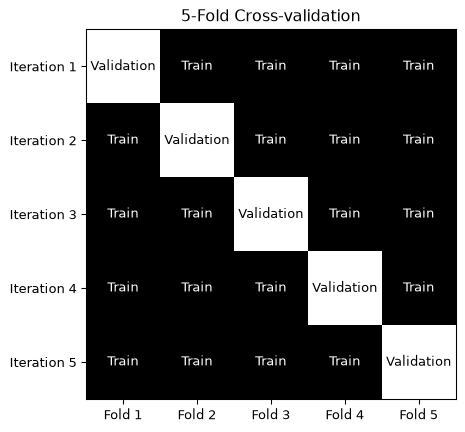

In [7]:
plot_k_fold_cross_validation(5)

With each iteration, $4/5$ of the training data is used for fitting and
$1/5$ for validation.

Each row represents one iteration. Every fold serves once as the
validation fold and four times as part of the training data. These folds
come only from the training portion of the original dataset. The
held-out test examples do not participate in this process.

## Evaluation across validation folds

- During model selection, cross-validation averages scores across
  **several validation folds** rather than relying on one validation
  partition.
- One score per fold reveals **sensitivity** to the particular
  validation examples.
- The **mean** and **standard deviation** summarize the fold scores, but
  the scores are not independent.

The final test set is also one finite sample, and its score depends on
which examples it contains. Its purpose is not to remove sampling
variability. Its purpose is to provide a final evaluation using examples
that did not influence model or hyperparameter selection.

Repeatedly consulting alternative test splits would allow their results
to influence model development and would gradually turn them into
validation data. When uncertainty in the final score matters, it should
be quantified using an appropriate confidence interval or bootstrap
procedure applied to the untouched test predictions. Nested
cross-validation or a genuinely independent external dataset provides
another option when a single holdout set is inadequate.

## Estimating generalization

- Cross-validation **estimates** performance on **unseen examples**
  drawn under similar conditions.
- It does not improve generalization by itself. It helps **compare
  model-building choices** using only the training data.
- The **untouched test set** provides the final evaluation after those
  choices have been made.

## Efficient use of data

- Cross-validation is particularly **useful when data is limited**.
- Across the $k$ iterations, **each training example** appears **once in
  a validation fold** and **$k-1$ times in a fitting fold**.
- After model selection, the chosen procedure can be refitted on the
  **complete training set**.

Examples need not be equally informative to the learning algorithm. The
composition of each fitting and validation fold can therefore affect its
score.

## Hyperparameter tuning

- Cross-validation compares candidate **hyperparameter settings** using
  the same folds and evaluation metric.
- The selected setting has the **best estimated performance** among the
  candidates that were evaluated.

The highest cross-validation score is used to select the hyperparameter
setting, so it can be somewhat optimistic. The final test evaluation
estimates the performance of the complete selection procedure on data
that did not influence that choice.

## Challenges

- **Computational cost:** Requires repeated model fitting.
  - **Leave-one-out** (LOO) is the extreme case where ( k = N ).
- **Class imbalance:** Random folds may not adequately represent
  minority classes.
  - Use **stratified cross-validation** to approximately maintain class
    proportions.
- **Implementation complexity:** Manual implementations are error-prone,
  especially for **nested cross-validation**, **bootstrap resampling**,
  or integration into larger pipelines.

Leave-one-out cross-validation fits the model once for every example.
Its training sets differ by only one example, which can produce a
high-variance estimate for some learning procedures and makes it
computationally expensive. Five- or ten-fold cross-validation is usually
a more practical default.

**Stratified cross-validation** approximately preserves the class
distribution in every fold so that each class is represented in the
fitting and validation partitions.

Ordinary random folds also assume that examples can be exchanged without
changing the problem. Repeated measurements from the same person require
group-aware folds, and predictions about the future require a time-aware
split.

# Hyperparameter tuning

## Workflow

![](https://scikit-learn.org/stable/_images/grid_search_workflow.png)

**Attribution**: <a
href="https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation"
class="external" data-icon="true">Cross-validation: evaluating estimator
performance</a>

This workflow distinguishes three uses of data: **training**,
**validation**, and **test**. The validation folds support model
selection, while the test set remains outside that process.

## Workflow: implementation

In [8]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
selection_metric = "roc_auc"

The test set is separated before cross-validation and hyperparameter
tuning. Stratification preserves approximately the same class
proportions in both partitions. The explicit cross-validation object
makes the folds reproducible and ensures that every model uses the same
validation splits.

AUROC is the selection metric throughout this example. Changing the
metric could change which hyperparameters and model are selected.

## Data leakage during cross-validation

**Data leakage** occurs when information from a validation fold
influences the procedure fitted on the remaining folds.

``` python
# Incorrect: the scaler sees every future validation fold

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

scores = cross_val_score(
    KNeighborsClassifier(),
    X_train_scaled,
    y_train,
    cv=cv,
)
```

The validation examples influence the means and scales used to evaluate
them.

Keeping the final test set untouched does not make this cross-validation
procedure valid. The call to `fit_transform` occurs before the folds are
created, so the scaler computes each feature’s mean and scale from all
of `X_train`. Every validation fold therefore contributes information to
its own preprocessing.

Applying `fit_transform` to the complete dataset `X` before creating the
train–test split would be even more serious. The fitted transformation
would then contain information from the test examples. Consequently, the
test set would no longer provide an independent evaluation of the
complete modelling procedure.

This is leakage even though scaling does not use the target labels. The
same problem applies to imputation, feature selection, principal
component analysis, resampling, and any other data-dependent operation
performed before cross-validation.

A pipeline prevents this form of leakage only for operations placed
inside the pipeline. It cannot correct target leakage, an inappropriate
time split, or repeated observations from one subject appearing in both
fitting and validation folds.

## `fit_transform` and `transform`

- `fit(X)` **learns** information from `X`.
- `fit_transform(X)` learns that information and **applies** the
  transformation to the same examples.
- `transform(X)` applies the **stored information** without recomputing
  it.

``` python
scaler = StandardScaler()

X_fitting_folds_scaled = scaler.fit_transform(X_fitting_folds)
X_validation_fold_scaled = scaler.transform(X_validation_fold)
```

Validation, test, and future examples receive `transform`, never `fit`
or `fit_transform`.

For `StandardScaler`, `fit` learns and stores attributes such as `mean_`
and `scale_`. For `SimpleImputer`, it stores the replacement value for
each feature in `statistics_`. Conceptually, `fit_transform(X)` performs
`fit(X)` followed by `transform(X)` on the same fitting examples.

Data leakage is a serious methodological problem. It has been the focus
of many sessions at machine learning conferences and workshops because
seemingly harmless preprocessing performed at the wrong stage can
invalidate an evaluation.

The fitted transformer retains this state in memory. A fitted pipeline
retains the state of every preprocessing step together with the
classifier’s learned parameters. Calling `predict` or `predict_proba` on
new examples automatically applies each stored transformation before
invoking the classifier.

Retaining state in memory is not the same as saving it permanently.
Deployment requires explicitly serializing the complete fitted pipeline
so that future examples receive the same transformations. Lecture 10
examines those engineering details.

## Preprocessing within each fold

For every fold, cross-validation creates and fits a **new pipeline**.

| Pipeline step | Fitting folds   | Validation fold                       |
|---------------|-----------------|---------------------------------------|
| Imputer       | `fit_transform` | `transform`                           |
| Scaler        | `fit_transform` | `transform`                           |
| Classifier    | `fit`           | `predict_proba` / `decision_function` |

Learned medians, means, and scales are not carried into the next fold.

For each iteration, scikit-learn clones the unfitted pipeline. Calling
`fit` on that pipeline fits each transformer on the fitting folds and
passes the transformed output to the next step. The classifier is then
fitted on the fully transformed fitting examples.

When the validation fold is scored, the pipeline calls only `transform`
on the imputer and scaler. Their stored statistics come exclusively from
the fitting folds. The temporary fitted pipeline is discarded after that
fold has been evaluated, and the next iteration begins with a new
unfitted clone.

`GridSearchCV` repeats this complete process for every hyperparameter
combination. After selecting a configuration, it refits that complete
pipeline on all the training data and retains it as `best_estimator_`.
The untouched test examples then receive only the transformations stored
in that final fitted pipeline.

## Preprocessing pipelines

In [9]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=seed)),
])

knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier()),
])

logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="saga",
        max_iter=3000,
        random_state=seed,
    )),
])

The imputer belongs inside each pipeline so that it learns its medians
from a fitting fold and applies them to the corresponding validation
fold. KNN and logistic regression also use standardized features because
their calculations depend on distances or coefficient optimization.
Decision trees split one feature at a time and do not require scaling.

The fixed value of `max_iter` gives the logistic-regression optimizer
enough iterations to converge. It is an implementation control, not a
model-complexity setting to be tuned for predictive performance.

## `cross_val_score`

In [10]:
knn_scores = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=selection_metric,
)

print("Scores:", knn_scores)
print(f"Mean AUROC: {knn_scores.mean():.3f}")
print(f"Standard deviation: {knn_scores.std():.3f}")

Scores: [0.81133721 0.76061047 0.84447674 0.74883721 0.75639881]
Mean AUROC: 0.784
Standard deviation: 0.037

<a
href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html"
class="external"
data-icon="true">sklearn.model_selection.cross_val_score</a>. See also
<a
href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate"
class="external" data-icon="true">cross_validate</a>.

Each score comes from a different validation fold. The mean summarizes
the five validation results. The standard deviation describes their
variation, but it is not a confidence interval because the fitted models
share many training examples.

Here, `cross_val_score` receives the complete KNN pipeline. It therefore
refits the imputer and scaler inside every fold before fitting the
classifier. Passing an array that had already been imputed or
standardized using all of `X_train` would bypass this protection.

## Model parameters and hyperparameters

**Model parameters** are learned from the training data.

**Hyperparameters** are chosen before each fit and control the model
structure or learning process.

Examples of hyperparameters include a tree’s `max_depth`, KNN’s
`n_neighbors`, and logistic regression’s `C`. Hyperparameter tuning uses
validation performance to choose among candidates. The learning
algorithm fits new model parameters for every candidate and every
cross-validation fold.

## Hyperparameters: decision tree

- `criterion`: chooses how the quality of a split is measured: `gini`,
  `entropy`, or `log_loss`.
- `max_depth`: limits the **maximum depth** of the tree.

**See**: <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html"
class="external" data-icon="true">DecisionTreeClassifier</a>

## Hyperparameters: logistic regression

- `C`: inverse regularization strength. Smaller values apply stronger
  regularization.
- `l1_ratio`: selects the balance between L2 and L1 regularization when
  the `saga` solver is used.

**See**: <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html"
class="external" data-icon="true">LogisticRegression</a>.

## Hyperparameters: KNN

- `n_neighbors`: number of neighbours used to make a prediction.
- `weights`: gives neighbours equal influence (`uniform`) or greater
  influence when they are closer (`distance`).

**See**: <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html"
class="external" data-icon="true">KNeighborsClassifier</a>

## Experiment: `n_neighbors`

In [11]:
neighbor_scores = {}
neighbor_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]

for value in neighbor_values:
    candidate = knn_pipeline.set_params(
        model__n_neighbors=value,
        model__weights="uniform",
    )
    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring=selection_metric,
    )
    neighbor_scores[value] = scores.mean()
    print(f"n_neighbors={value:2d}: {scores.mean():.3f}")

best_n_neighbors = max(neighbor_scores, key=neighbor_scores.get)
print("Best n_neighbors:", best_n_neighbors)

n_neighbors= 1: 0.664
n_neighbors= 3: 0.764
n_neighbors= 5: 0.784
n_neighbors= 7: 0.798
n_neighbors= 9: 0.815
n_neighbors=11: 0.822
n_neighbors=15: 0.832
n_neighbors=21: 0.831
n_neighbors=31: 0.831
Best n_neighbors: 15

## Experiment: `weights`

In [12]:
weight_scores = {}

for value in ["uniform", "distance"]:
    candidate = knn_pipeline.set_params(
        model__n_neighbors=best_n_neighbors,
        model__weights=value,
    )
    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring=selection_metric,
    )
    weight_scores[value] = scores.mean()
    print(f"weights={value:8s}: {scores.mean():.3f}")

weights=uniform : 0.832
weights=distance: 0.833

The first loop chooses `n_neighbors` while fixing `weights="uniform"`.
The second loop then fixes that chosen number of neighbours while
varying `weights`. This sequential procedure never revisits
`n_neighbors` after the weighting rule changes, so it can miss the best
pair of values.

Evaluating the Cartesian product of the two candidate sets addresses
that limitation. The code is straightforward to write with nested loops,
which makes grid search conceptually simple rather than a black box.

## Hyperparameter tuning: grid search

- Several hyperparameters may need to be considered **together**.

- Manual exploration of their combinations is **tedious and
  error-prone**.

- **Grid search** evaluates a predefined set of combinations
  systematically:

  1.  Enumerate the Cartesian product of the candidate values.

  2.  Evaluate each combination using the same cross-validation folds
      and metric.

The manual loops demonstrate that grid search can be implemented
independently. A standardized implementation adds several practical
benefits:

- It enumerates parameter combinations consistently.
- It applies every pipeline step separately within each fitting fold.
- It records fold-level and aggregate results in `cv_results_`.
- It exposes `best_params_`, `best_score_`, and a refitted
  `best_estimator_`.
- It supports several metrics, parallel execution, and explicit error
  reporting.
- It reduces indexing and bookkeeping mistakes and makes the experiment
  easier to reproduce.

The utility does not decide which metric, folds, models, or parameter
values are appropriate. Those choices remain part of the experimental
design.

## `GridSearchCV`: decision tree

In [13]:
from sklearn.model_selection import GridSearchCV

tree_param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, None],
    "model__criterion": ["gini", "entropy", "log_loss"],
}

tree_search = GridSearchCV(
    tree_pipeline,
    tree_param_grid,
    cv=cv,
    scoring=selection_metric,
)
tree_search.fit(X_train, y_train)

(tree_search.best_params_, tree_search.best_score_)

({'model__criterion': 'gini', 'model__max_depth': 4},
 np.float64(0.7881160022148395))

## `GridSearchCV`: KNN

In [14]:
knn_param_grid = {
    "model__n_neighbors": neighbor_values,
    "model__weights": ["uniform", "distance"],
}

knn_search = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=cv,
    scoring=selection_metric,
)
knn_search.fit(X_train, y_train)

(knn_search.best_params_, knn_search.best_score_)

({'model__n_neighbors': 21, 'model__weights': 'distance'},
 np.float64(0.8336620985603543))

The double underscore separates the pipeline-step name from the
estimator parameter. Grid search now evaluates every combination of
`n_neighbors` and `weights`, rather than committing to one value before
exploring the other.

With the current folds, sequential tuning selects 15 neighbours before
comparing the weighting rules. The joint grid instead selects 21
neighbours with distance weighting. The difference provides a concrete
example of an interaction between hyperparameters.

## `GridSearchCV`: logistic regression

In [15]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.0, 1.0],
}

logistic_search = GridSearchCV(
    logistic_pipeline,
    logistic_param_grid,
    cv=cv,
    scoring=selection_metric,
)
logistic_search.fit(X_train, y_train)

(logistic_search.best_params_, logistic_search.best_score_)

({'model__C': 0.1, 'model__l1_ratio': 0.0}, np.float64(0.8443867663344408))

With the `saga` solver, `l1_ratio=0` gives L2 regularization and
`l1_ratio=1` gives L1 regularization. Every candidate in this grid is
compatible with the fixed solver. The search varies properties of the
fitted model rather than convergence controls such as `max_iter` or
`tol`.

## Comparing tuned models

In [16]:
model_searches = {
    "Decision tree": tree_search,
    "KNN": knn_search,
    "Logistic regression": logistic_search,
}

for name, search in model_searches.items():
    print(f"{name:20s}: {search.best_score_:.3f}")

best_model_name = max(
    model_searches,
    key=lambda name: model_searches[name].best_score_,
)
best_search = model_searches[best_model_name]

print("Selected model:", best_model_name)

Decision tree       : 0.788
KNN                 : 0.834
Logistic regression : 0.844
Selected model: Logistic regression

The three searches use the same training examples, validation folds, and
AUROC metric. Their best cross-validation scores can therefore support a
choice among model families. This comparison is still part of model
selection, so it does not replace evaluation on the untouched test set.

Each `best_score_` is the highest score found within its search space
rather than an unbiased estimate of future performance. Comparing more
candidates creates more opportunities to select a setting that benefited
from these particular folds. The final test set provides an independent
estimate of the complete selection procedure’s performance.

## Randomized search

- A grid becomes expensive when it contains **many combinations**.
- `RandomizedSearchCV` samples candidates from supplied values or
  probability distributions.
- The number of iterations sets a predictable **computational budget**.

**See**: <a
href="https://scikit-learn.org/stable/auto_examples/model_selection/plot_randomized_search.html"
class="external" data-icon="true">Comparing randomized search and grid
search for hyperparameter estimation</a>.

## Workflow

![](https://scikit-learn.org/stable/_images/grid_search_workflow.png)

**Attribution**: <a
href="https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation"
class="external" data-icon="true">Cross-validation: evaluating estimator
performance</a>

The workflow now includes two levels of selection: hyperparameter
selection within each model family, followed by comparison of the three
tuned model families. Both levels use only the training data. The test
set remains isolated until the next step.

## Final evaluation

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

best_model = best_search.best_estimator_

y_test_score = best_model.predict_proba(X_test)[:, 1]
y_test_pred = best_model.predict(X_test)

print("Selected model:", best_model_name)
print(f"Test AUROC: {roc_auc_score(y_test, y_test_score):.3f}")
print(classification_report(y_test, y_test_pred))

Selected model: Logistic regression
Test AUROC: 0.810
              precision    recall  f1-score   support

           0       0.74      0.80      0.77       100
           1       0.57      0.48      0.52        54

    accuracy                           0.69       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.68      0.69      0.68       154


After this evaluation, the modelling procedure remains **frozen**.
Revising it and evaluating again on the same test set uses the test
result during model development.

By default, `GridSearchCV` refits the selected hyperparameter
configuration on the complete training set. The `best_estimator_` is
therefore ready for the one-time test evaluation.

AUROC matches the metric used during model selection. The classification
report complements it with threshold-dependent precision, recall, and
$F_1$ scores. The test result estimates how the complete, frozen
selection procedure will perform on unseen examples drawn under similar
conditions.

A disappointing result creates a strong temptation to revise the
preprocessing, features, models, hyperparameter search, or evaluation
metric and then try again. At that point, the observed test performance
has influenced model development, and the test set effectively functions
as validation data. This adaptive reuse is often described as *training
on the test set*, even though the learning algorithm is not fitted
directly to the test examples.

The objective is an honest estimate of deployed performance rather than
the highest possible reported score. If further development is
necessary, the existing test set can no longer provide a fully
independent final evaluation of the revised procedure. That evaluation
requires a new untouched test set or an independent external dataset.

# Closing Material

## Summary

- Reserved an untouched **test set** for one final evaluation after all
  model-building choices.
- Used **$k$-fold cross-validation** to train a new model in each
  iteration and summarize the related fold scores with their mean and
  standard deviation.
- Prevented **data leakage** by fitting imputation and scaling inside
  each fold, then applying the stored transformations to validation and
  test examples.
- Distinguished learned **model parameters** from **hyperparameters**
  and evaluated interacting hyperparameters jointly.
- Used `GridSearchCV` to tune and compare decision tree, KNN, and
  logistic regression pipelines with the same folds and AUROC metric.
  **Randomized search** provides an alternative for larger search
  spaces.
- Refit the selected pipeline on all training data and evaluated it once
  on the test set. Further model changes would turn that test set into
  validation data.

## Next lecture

- After the quiz, we will examine machine learning engineering.

## References

Russell, Stuart, and Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4th ed. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

School of Electrical Engineering and **Computer Science** (EE**CS**)

University of Ottawa